# VN Gold Decision Support: EDA, Literature Review And Modeling

## tl;dr
This notebook is the reproducible companion for the VN gold decision-support report. It reads the generated modeling artifacts by default so validation is fast, and can rebuild the full model suite by setting `RUN_MODELING = True`.

The target is net execution return after spread: `buy_price_{t+h} / sell_price_t - 1` for 21, 63 and 105 trading-day horizons.

## Context & Methods

### Key Assumptions
- The decision is evaluated as buying at SJC `sell_price_t` and exiting at `buy_price_{t+h}`.
- Global and US market features are joined as-of `date - 1 day`.
- Vietnam macro features are joined through `available_from <= date`, not observation date.
- Deposit rates are excluded because the crawled `deposit_rates_vn.csv` values are null.
- DeepAR and TFT are documented as production candidates; this notebook records dependency/runtime blockers instead of forcing heavy training.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from gold_collectors.modeling import ModelingConfig, run_full_analysis

RUN_MODELING = False
config = ModelingConfig()
if RUN_MODELING:
    summary = run_full_analysis(config)
else:
    summary_path = config.output_dir / "analysis_summary.json"
    if not summary_path.exists():
        summary = run_full_analysis(config)
    else:
        summary = json.loads(summary_path.read_text(encoding="utf-8"))

summary

{'generated_at': '2026-07-13T03:28:31.798092',
 'rows': 5485,
 'date_min': '2011-07-06',
 'date_max': '2026-07-11',
 'premium_missing_rate': 0.3358249772105743,
 'deposit_rate_feature': 'excluded_value_null_100pct',
 'blockers': ['VECM cointegration screen passed; VECM forecast not promoted in v1 notebook.',
  "LightGBM unavailable; using sklearn quantile fallback: No module named 'lightgbm'",
  "XGBoost unavailable: No module named 'xgboost'",
  'DeepAR/TFT skipped: missing optional dependencies torch, pytorch_forecasting, gluonts',
  'Data diagnostics: {"raw_news_headline_rows": 3441, "raw_news_headline_unique_days": 702, "raw_news_headline_coverage": 0.12798541476754785, "raw_news_modeling_status": "included_event_date_asof_lagged", "raw_news_leakage_caveat": "Google RSS was backfilled in 2026; event_date is treated as article publication date and lagged t-1, but strict real-time crawl availability is not proven."}'],
 'target_non_null': {'net_return_21d': 5464,
  'net_return_63d': 

## Data

Load the model frame, leaderboard, walk-forward predictions and decision signals generated by the runner.

In [2]:
model_frame = pd.read_csv(config.output_dir / "model_frame_daily.csv", parse_dates=["date", "global_feature_date", "gpr_feature_date", "macro_feature_date"])
results = pd.read_csv(config.output_dir / "model_results.csv")
predictions = pd.read_csv(config.output_dir / "walk_forward_predictions.csv", parse_dates=["date"])
signals = pd.read_csv(config.output_dir / "decision_signals.csv", parse_dates=["date"])

print(model_frame.shape)
print(results.shape, predictions.shape, signals.shape)
model_frame[["date", "sell_price", "buy_price", "premium", "global_feature_date", "gpr_feature_date", "macro_feature_date"]].head()

(5485, 715)
(126, 8) (38940, 8) (28242, 15)


,date,sell_price,buy_price,premium,global_feature_date,gpr_feature_date,macro_feature_date
0,2011-07-06,37740000.0,37680000.0,-7882561.65,2011-07-05,2011-07-05,2011-07-01
1,2011-07-07,37840000.0,37780000.0,-7770091.86,2011-07-06,2011-07-06,2011-07-01
2,2011-07-08,37820000.0,37760000.0,-8139375.73,2011-07-07,2011-07-07,2011-07-01
3,2011-07-09,37980000.0,37920000.0,NaN,2011-07-08,2011-07-08,2011-07-01
4,2011-07-10,37980000.0,37920000.0,NaN,2011-07-08,2011-07-09,2011-07-01


In [3]:
coverage = pd.DataFrame({
    "metric": ["rows", "date_min", "date_max", "premium_missing_rate", "news_sentiment_coverage"],
    "value": [
        len(model_frame),
        model_frame["date"].min().date(),
        model_frame["date"].max().date(),
        model_frame["premium"].isna().mean(),
        json.loads(summary["blockers"][-1].replace("Data diagnostics: ", "")).get("news_sentiment_coverage") if summary.get("blockers") and "Data diagnostics" in summary["blockers"][-1] else np.nan,
    ],
})
coverage

,metric,value
0,rows,5485
1,date_min,2011-07-06
2,date_max,2026-07-11
3,premium_missing_rate,0.335825
4,news_sentiment_coverage,None


## Results

### Price decomposition and target behavior
The first visual compares domestic SJC sell price with the global-gold VND/l??ng proxy and premium when available.

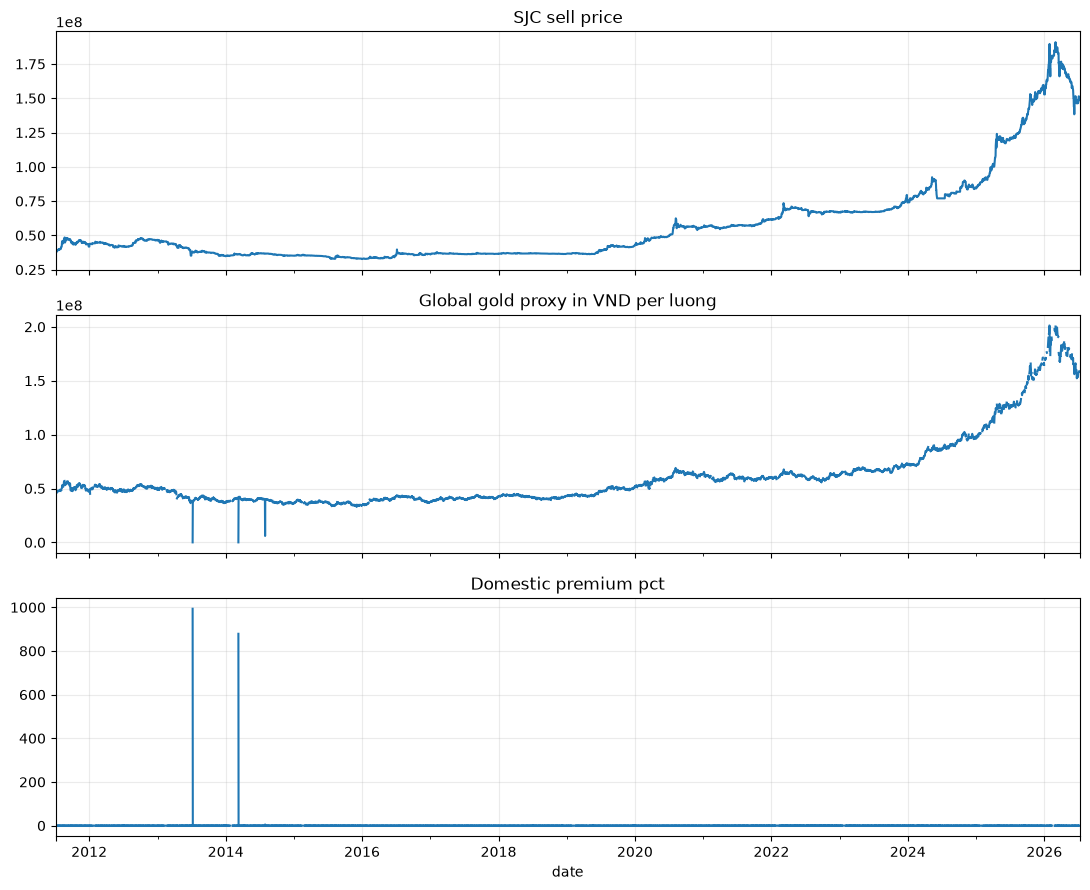

In [4]:
plot_df = model_frame.set_index("date")
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
plot_df["sell_price"].plot(ax=axes[0], title="SJC sell price")
plot_df["global_gold_vnd_per_luong"].plot(ax=axes[1], title="Global gold proxy in VND per luong")
plot_df["premium_pct"].plot(ax=axes[2], title="Domestic premium pct")
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()

In [5]:
target_summary = []
for horizon in config.horizons:
    col = f"net_return_{horizon}d"
    target_summary.append({
        "horizon_days": horizon,
        "n": int(model_frame[col].notna().sum()),
        "mean": model_frame[col].mean(),
        "median": model_frame[col].median(),
        "p10": model_frame[col].quantile(0.10),
        "p90": model_frame[col].quantile(0.90),
        "positive_rate": (model_frame[col] > 0).mean(),
    })
pd.DataFrame(target_summary)

,horizon_days,n,mean,median,p10,p90,positive_rate
0,21,5464,-0.004315,-0.006476,-0.028643,0.023360,0.313400
1,63,5422,0.006471,-0.004488,-0.044773,0.080167,0.430447
2,105,5380,0.018298,-0.000601,-0.061350,0.121163,0.479307


### Model leaderboard
Lower MAE is better for mean-return models; quantile models are compared with pinball loss.

In [6]:
leaderboard = (
    results.groupby(["model", "horizon_days"], as_index=False)
    .agg(mae=("mae", "mean"), rmse=("rmse", "mean"), directional_accuracy=("directional_accuracy", "mean"), pinball_loss=("pinball_loss", "mean"))
    .sort_values(["horizon_days", "mae"], na_position="last")
)
leaderboard.head(30)

,model,horizon_days,mae,rmse,directional_accuracy,pinball_loss
18,sarimax_exog,21,0.023647,0.035868,0.567123,NaN
6,historical_median_return,21,0.032064,0.044944,0.590135,NaN
3,historical_mean_return,21,0.032254,0.045106,0.590135,NaN
9,naive_zero_return,21,0.032652,0.045398,0.015054,NaN
0,elastic_net,21,0.045530,0.057313,0.495075,NaN
15,ridge,21,0.055080,0.067981,0.477984,NaN
12,random_forest,21,0.061503,0.070930,0.639659,NaN
21,sklearn_gbr_q05,21,NaN,NaN,NaN,0.006980
24,sklearn_gbr_q10,21,NaN,NaN,NaN,0.011867
27,sklearn_gbr_q50,21,NaN,NaN,NaN,0.020318


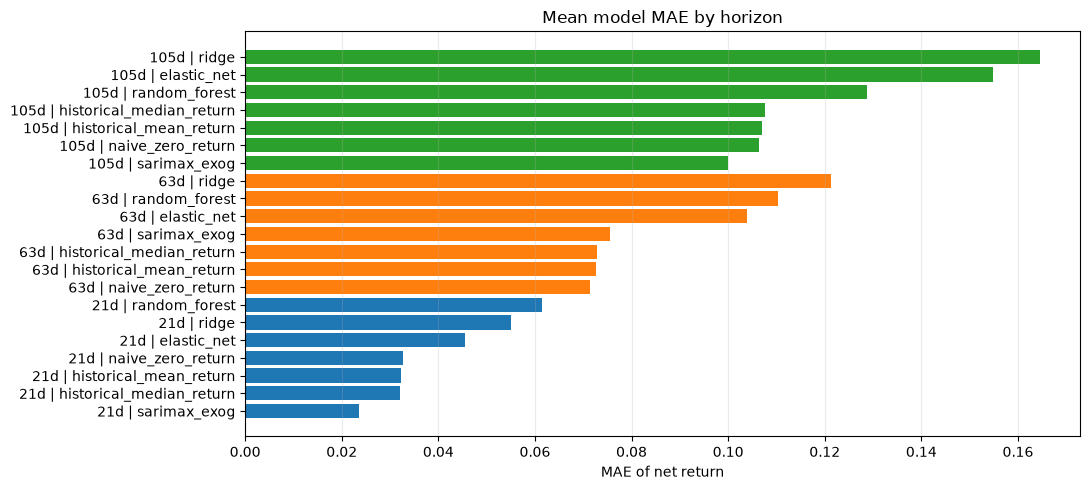

In [7]:
mean_models = leaderboard.dropna(subset=["mae"]).copy()
fig, ax = plt.subplots(figsize=(11, 5))
for horizon, group in mean_models.groupby("horizon_days"):
    group = group.sort_values("mae").head(8)
    ax.barh([f"{horizon}d | {m}" for m in group["model"]], group["mae"])
ax.set_title("Mean model MAE by horizon")
ax.set_xlabel("MAE of net return")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()

### Decision signals
Default rule: buy when `P(net_return > 0) >= 0.60` and q10 predicted return is at least `-5%`. Sensitivity rows for other thresholds are also saved in `decision_signals.csv`.

In [8]:
default_signals = signals[(signals["prob_threshold"].eq(config.decision_prob_threshold)) & (signals["q10_floor"].eq(config.decision_q10_floor))]
decision_summary = (
    default_signals.groupby(["horizon_days", "phase"], as_index=False)
    .agg(signal_days=("buy_signal", "sum"), observations=("buy_signal", "count"), avg_strategy_return=("strategy_return", "mean"), avg_realized_return=("actual_net_return", "mean"))
)
decision_summary

,horizon_days,phase,signal_days,observations,avg_strategy_return,avg_realized_return
0,21,test,4,365,0.000184,0.019503
1,21,validation,0,365,0.000000,-0.005466
2,63,test,0,494,0.000000,0.060635
3,63,validation,0,731,0.000000,0.005063
4,105,test,0,452,0.000000,0.127626
5,105,validation,0,731,0.000000,0.027695


C:\Users\admin\AppData\Local\Temp\ipykernel_37376\1036492050.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = group.set_index("date")["buy_signal"].resample("M").sum()
C:\Users\admin\AppData\Local\Temp\ipykernel_37376\1036492050.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = group.set_index("date")["buy_signal"].resample("M").sum()
C:\Users\admin\AppData\Local\Temp\ipykernel_37376\1036492050.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = group.set_index("date")["buy_signal"].resample("M").sum()


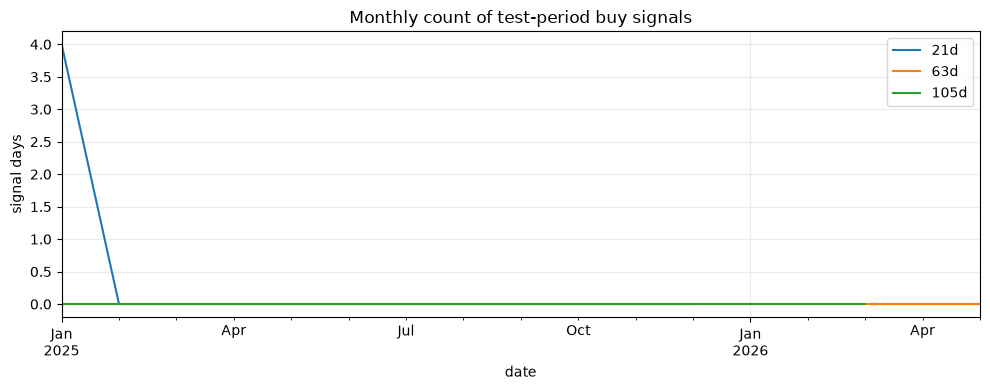

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
for horizon, group in default_signals[default_signals["phase"].eq("test")].groupby("horizon_days"):
    monthly = group.set_index("date")["buy_signal"].resample("M").sum()
    monthly.plot(ax=ax, label=f"{horizon}d")
ax.set_title("Monthly count of test-period buy signals")
ax.set_ylabel("signal days")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()

## Takeaways

- The modeling frame is usable for research-grade EDA and baseline forecasting, with explicit leakage controls.
- Premium coverage and missing deposit-rate history are the main blockers before this can become production-grade decision support.
- SARIMAX is competitive in this run, while tree/linear ML needs tighter feature selection and stronger exogenous data before it should be trusted.
- The default buy rule is conservative in the executed artifacts, producing few test-period signals; threshold sensitivity should be reviewed before any policy interpretation.

In [10]:
assert set(config.horizons).issubset(set(results["horizon_days"].dropna().astype(int)))
assert set(config.horizons).issubset(set(predictions["horizon_days"].dropna().astype(int)))
assert set(config.horizons).issubset(set(signals["horizon_days"].dropna().astype(int)))
assert (model_frame["global_feature_date"] <= model_frame["date"]).dropna().all()
assert (model_frame["gpr_feature_date"] <= model_frame["date"]).dropna().all()
print("Notebook validation checks passed")

Notebook validation checks passed
